In [11]:
# --- 修正版: JSON(config) と PyTorch(checkpoint) を分けて読む ---
import os
import json
import torch

#path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/config.json"
# 例: 重みを見たいならこちらに差し替え
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth"

def dump_dict(d, prefix=""):
    if isinstance(d, dict):
        for k, v in d.items():
            name = f"{prefix}{k}"
            if isinstance(v, dict):
                print(f"{name}/")
                dump_dict(v, prefix=name + ".")
            elif torch.is_tensor(v):
                print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
            else:
                print(f"{name:60s} | type={type(v)}")
    else:
        # dict以外が来たときの保険
        print(f"{prefix.rstrip('.')}: {type(d)}")

ext = os.path.splitext(path)[1].lower()

if ext == ".json":
    with open(path) as f:
        cfg = json.load(f)
    dump_dict(cfg)
else:
    ckpt = torch.load(path, map_location="cpu")
    state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
    dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_sigma                      | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_mu                         | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 64) | dtype=torch.float32
net

In [ ]:
import torch

def ptq_weight_nonzero(
    params: torch.Tensor, 
    n_bits: int = 4, 
    percentile: float = 0.999, 
    gaussian: float = None, 
    symmetric: bool = True
):
    """
    ReRAM CiM向け: スパース性を維持しつつ、書き込み目標値の量子化と読み出しノイズを印加する関数
    
    Args:
        params: 重みテンソル (Float)
        n_bits: ビット数 (例: 4bitなら16レベル)
        percentile: 外れ値除去のためのクリッピング率 (0.999推奨)
        gaussian: 正規化されたノイズ標準偏差 (例: 0.3 = 1LSBの30%のノイズ)
        symmetric: True推奨 (2T2R差動ペア構成を想定)
    """
    assert n_bits >= 2
    if percentile > 1.0:
        percentile /= 100.0

    with torch.no_grad():
        # 元の重みをコピー (0の部分はここでコピーされたまま、最後までいじらない = 完全な0/OFF)
        x = params.to(torch.float32)
        out = x.clone()

        # ---------------------------------------------------
        # 1. Zero-Gating (物理的なスイッチOFF)
        # ---------------------------------------------------
        # 0以外の要素(Non-zero)だけを取り出す
        nz_mask = x != 0
        nz = x[nz_mask]

        if nz.numel() == 0:
            return out # 全て0ならそのまま返す

        # ---------------------------------------------------
        # 2. Clipping (書き込み目標範囲の決定)
        # ---------------------------------------------------
        # 外れ値があると1LSBの幅(scale)が歪むため、percentileでクリッピングする
        if symmetric:
            abs_nz = nz.abs()
            max_val = torch.quantile(abs_nz, percentile)
            # ReRAMは正負対称のダイナミックレンジを持つと仮定
            nz = torch.clamp(nz, min=-max_val, max=max_val)
        else:
            # 非対称の場合はmin/maxを使う
            lower = torch.quantile(nz, 1 - percentile)
            upper = torch.quantile(nz, percentile)
            nz = torch.clamp(nz, min=lower, max=upper)

        # ---------------------------------------------------
        # 3. Quantization (書き込み: Target Conductanceの決定)
        # ---------------------------------------------------
        if symmetric:
            # [重要] 0をレベルとして確保するため、最大レベルを (2^(N-1) - 1) にする
            # 例 4bit: 符号1bit + データ3bit => 最大値7 (-7 ~ +7, 0含む15レベル)
            qmax = 2 ** (n_bits - 1) - 1
            
            # 最大値をqmaxにマッピングするためのスケール(1LSBの幅)を計算
            abs_max_clipped = nz.abs().max()
            if abs_max_clipped < 1e-12: return out
            
            scale = abs_max_clipped / qmax
            
            # ここで「書き込み目標値」が決まる (整数レベルに丸めて、スケール倍する)
            # これが "Ideal Written Weight"
            nz_target = torch.round(nz / scale).clamp(-qmax, qmax) * scale

        else:
            # Asymmetric (Unsigned想定だが、重みは通常SignedなのでReRAMではあまり使わない)
            qmax = 2 ** n_bits - 2
            min_val = nz.min()
            max_val = nz.max()
            if max_val - min_val < 1e-12: return out
            
            scale = (max_val - min_val) / qmax
            nz_target = torch.round((nz - min_val) / scale).clamp(0, qmax) * scale + min_val

        # ---------------------------------------------------
        # 4. Noise Injection (読み出し: Analog Readout Noise)
        # ---------------------------------------------------
        # ADCを通す前の「アナログ電流値」をシミュレートする。
        # したがって、ノイズ加算後は round(丸め) してはいけない。
        
        if gaussian is not None and gaussian > 0.0:
            # ノイズの定義: 1LSB (scale) に対する割合
            # normalized_sigma = gaussian * scale
            noise = torch.randn_like(nz_target) * gaussian * scale
            
            # [物理現象] ターゲット値 + ノイズ
            # これが実際にMVM演算に使われるコンダクタンス
            nz_noisy = nz_target + noise
            
            # [物理制約] デバイスのダイナミックレンジ(飽和)
            # ノイズが乗っても、物理的な最大コンダクタンス以上は流れない
            if symmetric:
                # abs_max_clipped はその層の最大コンダクタンス相当
                nz_final = nz_noisy.clamp(-abs_max_clipped, abs_max_clipped)
            else:
                nz_final = nz_noisy.clamp(min_val, max_val)
        else:
            nz_final = nz_target

        # ---------------------------------------------------
        # 5. Write Back
        # ---------------------------------------------------
        # 計算した非ゼロ部分だけを元のテンソルに戻す
        # (nz_mask以外、つまり0の部分は触っていないので 0.0 のまま = ノイズレス)
        out[nz_mask] = nz_final

        return out.to(params.dtype)

Loading checkpoint: /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth


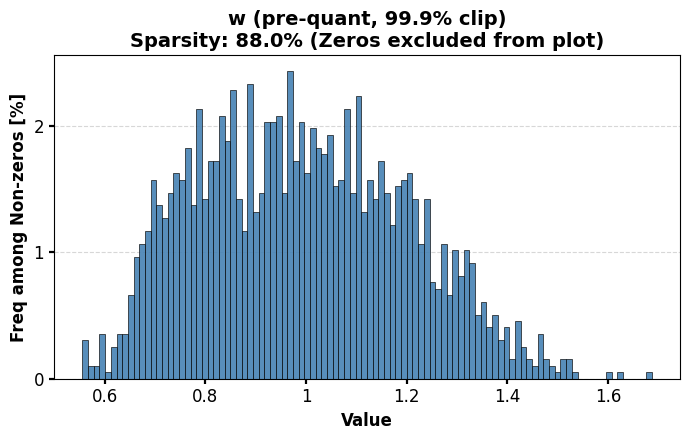

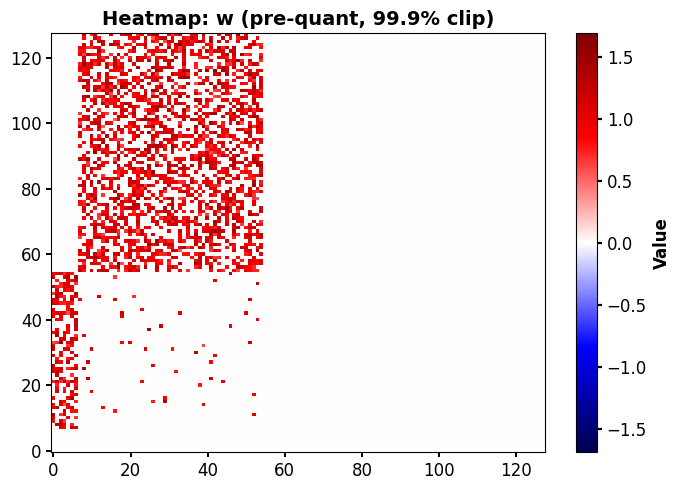

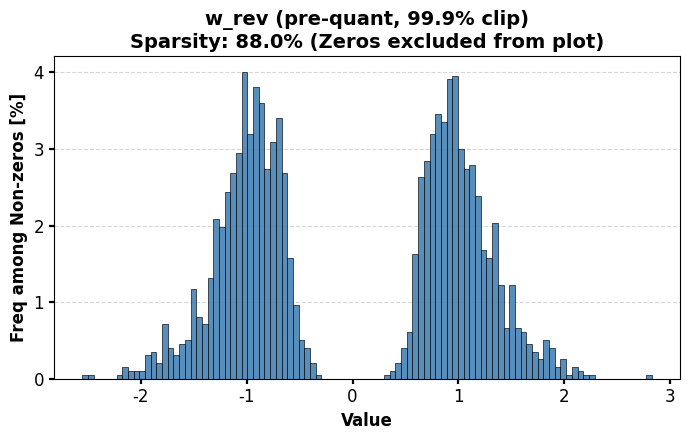

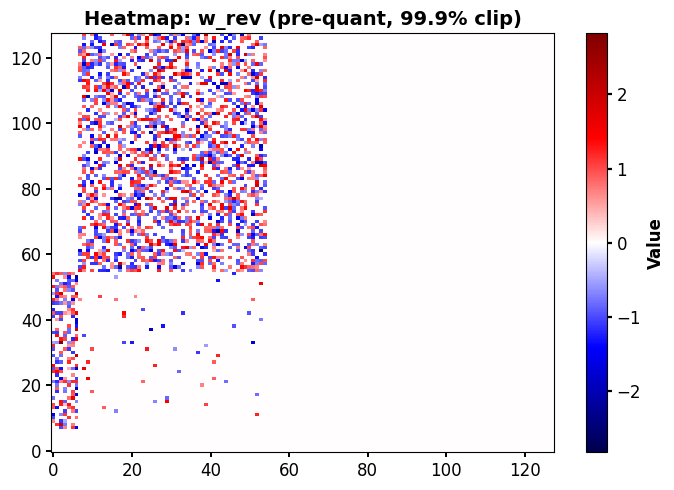

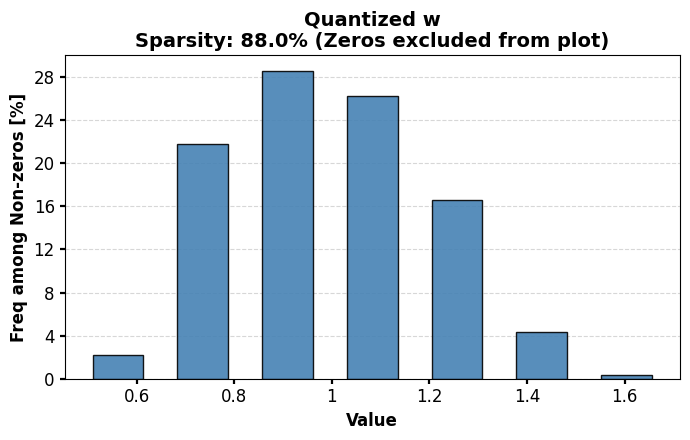

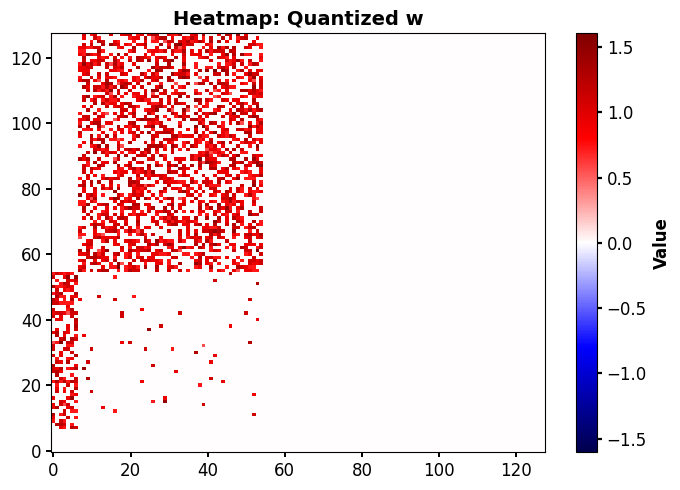

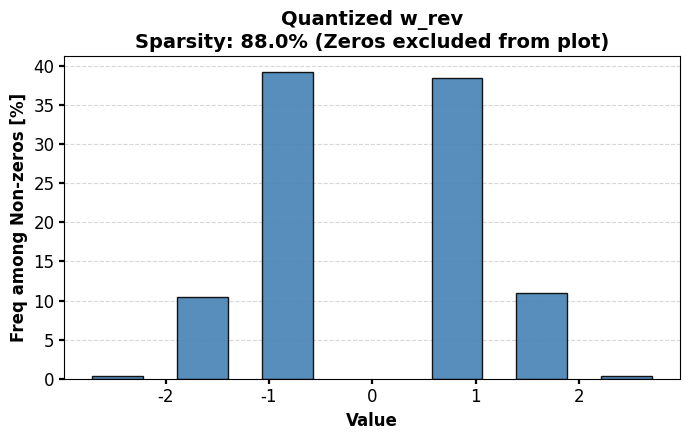

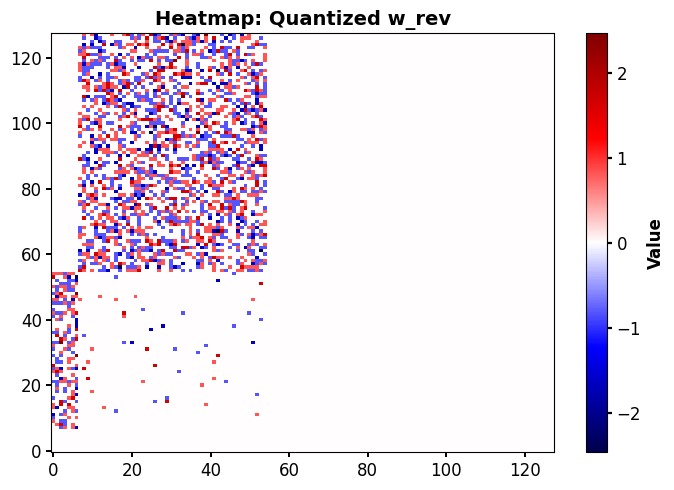

In [23]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

# 出力省略の解除
np.set_printoptions(threshold=np.inf)

# ------------------------------------------------------------------
# state_dict flatten（int key 対応）
# ------------------------------------------------------------------
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        k = str(k)
        if isinstance(v, dict):
            out.update(flatten(v, prefix + k + "."))
        else:
            out[prefix + k] = v
    return out

# ------------------------------------------------------------------
# プロット関数（修正版）
# ------------------------------------------------------------------
def plot_separated_stages(checkpoint_path: str):
    print(f"Loading checkpoint: {checkpoint_path}")
    try:
        state = torch.load(checkpoint_path, map_location="cpu")
    except FileNotFoundError:
        print("Error: Checkpoint file not found.")
        return

    if "state_dict" in state:
        state = state["state_dict"]

    flat = flatten(state)
    
    # 必要なキーを検索（部分一致）
    try:
        w_key = [k for k in flat if k.endswith("rnn_cell.w")][0]
        mask_key = [k for k in flat if k.endswith("rnn_cell.sparsity_mask")][0]
        erev_key = [k for k in flat if k.endswith("rnn_cell.erev")][0]
    except IndexError:
        print("Error: Could not find required keys (rnn_cell.w/mask/erev) in checkpoint.")
        return

    w = flat[w_key]
    mask = flat[mask_key]
    erev = flat[erev_key]

    # ---------------- 前処理 ----------------
    w_masked = F.softplus(w) * mask
    w_rev = w_masked * erev
    stages = [
        ("w (pre-quant, 99.9% clip)", w_masked, "continuous"),
        ("w_rev (pre-quant, 99.9% clip)", w_rev, "continuous"),
        ("Quantized w", ptq_weight_nonzero(w_masked.clone(), n_bits=3, percentile=99.9, symmetric=False), "discrete"),
        ("Quantized w_rev", ptq_weight_nonzero(w_rev.clone(), n_bits=3, percentile=99.9, symmetric=True), "discrete"),
    ]

    for name, data, mode in stages:
        arr = data.detach().cpu().numpy().flatten()
        
        # --- スパース性の計算 ---
        total_count = len(arr)
        zero_count = np.sum(arr == 0)
        sparsity = zero_count / total_count
        nz = arr[arr != 0]

        # ---------------- ヒストグラム ----------------
        plt.figure(figsize=(7, 4.5)) # 少し横長に

        if len(nz) == 0:
            plt.text(0.5, 0.5, "All values are Zero", ha='center', va='center', fontsize=14)
        else:
            if mode == "continuous":
                # 重みを「非ゼロ要素数」に対する割合にする
                weights = np.ones_like(nz) / len(nz) * 100
                plt.hist(
                    nz,
                    bins=100,
                    weights=weights,
                    color="steelblue",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                    alpha=0.9
                )
            else:
                # 離散値のプロット
                vals, counts = np.unique(nz, return_counts=True)
                weights = counts / counts.sum() * 100
                # 棒の幅を自動調整
                step = np.min(np.diff(vals)) if len(vals) > 1 else 0.2
                plt.bar(
                    vals,
                    weights,
                    width=step * 0.6,
                    color="steelblue",
                    edgecolor="black",
                    zorder=2,
                    alpha=0.9
                )

        ax = plt.gca()
        
        # タイトルにスパース率を表示（これが重要！）
        ax.set_title(f"{name}\nSparsity: {sparsity:.1%} (Zeros excluded from plot)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Freq among Non-zeros [%]", fontsize=12, fontweight='bold')
        ax.set_xlabel("Value", fontsize=12, fontweight='bold')

        ax.tick_params(axis="both", labelsize=12, width=1.6)
        
        # Y軸を整数目盛りにする（見やすさのため）
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        
        # X軸フォーマット
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2g}")) # 指数表記回避

        # グリッド
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

        # ---------------- ヒートマップ ----------------
        # 0とそれ以外を視覚的に区別しやすいようにプロット
        mat = data.detach().cpu().numpy()
        
        # 最大値で正規化範囲を決定
        vmax = np.max(np.abs(mat))
        if vmax == 0: vmax = 1.0
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        plt.figure(figsize=(7, 5))
        plt.imshow(
            mat,
            cmap="seismic",
            norm=norm,
            aspect="auto",
            interpolation="nearest",
            origin="lower" # 行列の上下を合わせる
        )
        cbar = plt.colorbar()
        cbar.ax.tick_params(labelsize=12, width=1.6)
        cbar.set_label("Value", fontweight='bold', fontsize=12)
        
        ax = plt.gca()
        ax.set_title(f"Heatmap: {name}", fontsize=14, fontweight='bold')
        ax.tick_params(axis="both", labelsize=12, width=1.4)

        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------
# 実行パスの設定
# ------------------------------------------------------------------
# パスは環境に合わせて変更してください
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth"
plot_separated_stages(path)

-1.558022141456604 1.5862164497375488


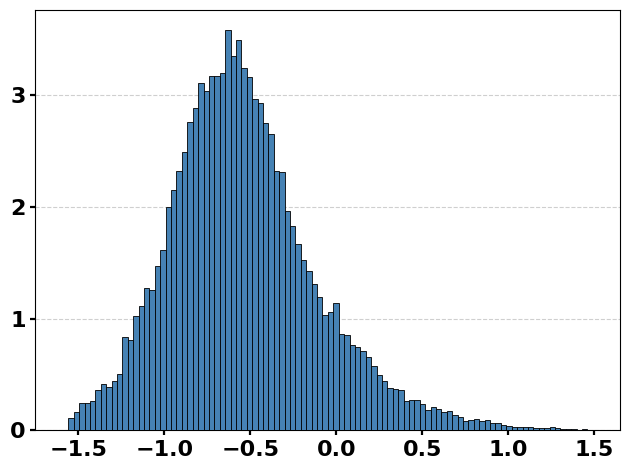

2.182774849757152e-09 0.9999516010284424


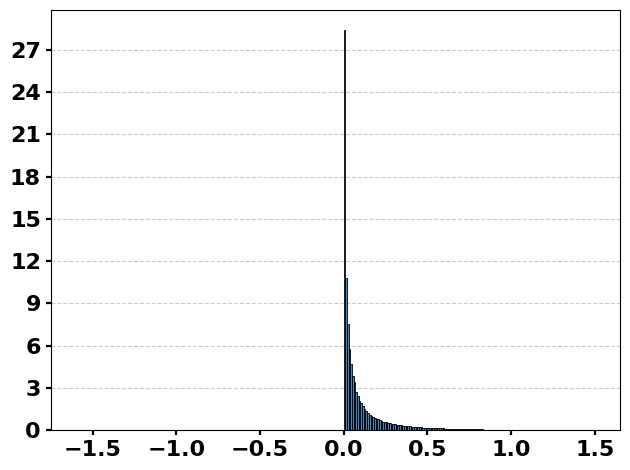

In [14]:
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# load
# =========================
with open("/work/robomimic/quantize_logs/base.json") as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

# =========================
# 共通ヒスト作成関数
# =========================
def plot_hist_resampled(data, key="states", n_bins=100, as_percent=False, title=None):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])

    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    hist_sum = np.zeros(n_bins)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                if w > 0:
                    hist_sum[idx] += cnt / w  # density 換算
                else:
                    hist_sum[idx] += cnt

    if as_percent:
        hist_sum = hist_sum / hist_sum.sum() * 100.0

    centers = 0.5 * (edges_common[:-1] + edges_common[1:])
    widths = np.diff(edges_common)

    plt.bar(centers, hist_sum, width=widths, align="center",
            edgecolor="black", linewidth=0.6, color="steelblue", zorder=3)
    plt.xlim(-1.75, 1.65)
    print(vmin, vmax)

    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.tick_params(axis="both", labelsize=16, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# =========================
# 可視化
# =========================
plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=True,
    title="States histogram (resampled, summed)"
)

plot_hist_resampled(
    data,
    key="activations",
    n_bins=100,
    as_percent=True,
    title="Activations histogram (resampled, summed)"
)


CDF 0.05–99.95%
[-1.544, 1.318]


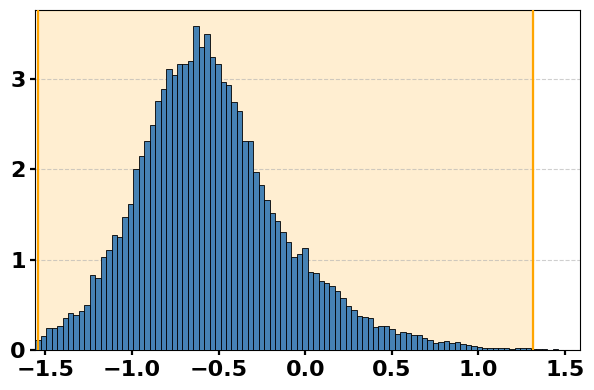

CDF 5–99%
[0.00176, 0.7669]


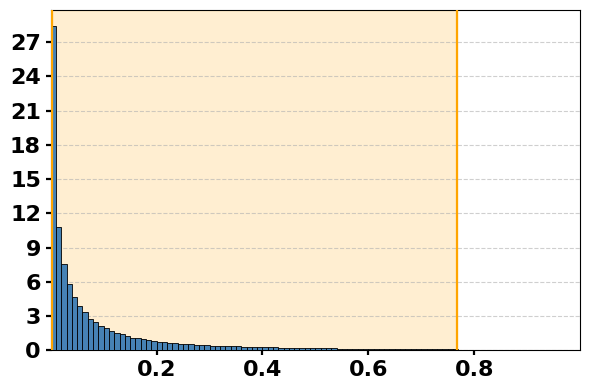

In [15]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=False,
    title=None,
    percent_band=(5.0, 95.0),   # 追加: ここで「何%〜何%」を指定
    band_color="orange",
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths = np.diff(edges_common)
    centers = 0.5 * (edges_common[:-1] + edges_common[1:])

    # hist_sum は「density相当」を足し上げている（cnt / bin_width）
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # ---- 何%の範囲(=CDF)を可視化するために「確率質量」を作る ----
    # density * dx -> mass（各ビンが全体の何%を占めるか）
    mass = hist_sum * widths
    mass_total = mass.sum()

    # percent_band から x 座標を求める（累積分布を edges 上で補間）
    x_lo = x_hi = None
    if percent_band is not None and mass_total > 0:
        lo, hi = percent_band
        lo = float(lo); hi = float(hi)
        if not (0.0 <= lo <= 100.0 and 0.0 <= hi <= 100.0 and lo < hi):
            raise ValueError("percent_band must satisfy 0<=lo<hi<=100")

        cdf_edges = np.concatenate([[0.0], np.cumsum(mass)]) / mass_total * 100.0  # len = n_bins+1
        x_lo = float(np.interp(lo, cdf_edges, edges_common))
        x_hi = float(np.interp(hi, cdf_edges, edges_common))

    # ---- 表示用に % 正規化（y 軸表示） ----
    y = hist_sum.copy()
    if as_percent:
        if y.sum() > 0:
            y = y / y.sum() * 100.0

    plt.figure(figsize=(6, 4))
    plt.bar(
        centers, y, width=widths, align="center",
        edgecolor="black", linewidth=0.6, color="steelblue", zorder=3
    )
    plt.xlim(vmin, vmax)


    # ---- 「何%の範囲はここ」を重ねて表示 ----
    ax = plt.gca()
    if x_lo is not None and x_hi is not None:
        ax.axvspan(x_lo, x_hi, color=band_color, alpha=0.18, zorder=1, label=f"{percent_band[0]:g}–{percent_band[1]:g}%")
        ax.axvline(x_lo, color=band_color, linewidth=1.6, zorder=4)
        ax.axvline(x_hi, color=band_color, linewidth=1.6, zorder=4)
        print(f"CDF {percent_band[0]:g}–{percent_band[1]:g}%\n[{x_lo:.4g}, {x_hi:.4g}]")


    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.tick_params(axis="both", labelsize=16, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 例: 中央90% (= 5–95%) を表示
plot_hist_resampled(data, key="states", n_bins=100, as_percent=True, title="States histogram", percent_band=(0.05, 99.95))
plot_hist_resampled(data, key="activations", n_bins=100, as_percent=True, title="Activations histogram", percent_band=(5, 99))
# ...existing code...

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# Load JSON
# =========================
json_path = "/work/robomimic/quantize_logs/base.json"
with open(json_path) as f:
    data_states = json.load(f)
if not data_states:
    raise ValueError("data is empty")

# =========================
# ヒストグラム統合
# =========================
def quantize_histogram(hist, edges, n_bits=4, clip_min=None, clip_max=None, symmetric=True):
    """
    ヒストグラムを(ビン中心ベースで)量子化して、量子化後の中心 uniq_q と集約ヒスト q_hist を返す。

    - clip_min/clip_max が None の場合は、hist>0 のビン中心から自動推定
      * symmetric=True  : [-absmax, +absmax]
      * symmetric=False : [min, max]
    """
    hist = np.asarray(hist, dtype=float)
    edges = np.asarray(edges, dtype=float)

    centers = 0.5 * (edges[:-1] + edges[1:])

    # --- 自動レンジ推定（clip 範囲を決めなくてよい） ---
    if clip_min is None or clip_max is None:
        nz = hist > 0
        if not np.any(nz):
            # データが空ならそのまま返す
            return np.array([0.0]), np.array([0.0])

        c_nz = centers[nz]
        if symmetric:
            absmax = float(np.max(np.abs(c_nz)))
            if absmax <= 0.0:
                return np.array([0.0]), np.array([hist.sum()])
            clip_min = -absmax
            clip_max = +absmax
        else:
            clip_min = float(np.min(c_nz)) if clip_min is None else float(clip_min)
            clip_max = float(np.max(c_nz)) if clip_max is None else float(clip_max)

    clip_min = float(clip_min)
    clip_max = float(clip_max)

    if clip_max <= clip_min:
        raise ValueError(f"invalid clip range: clip_min={clip_min}, clip_max={clip_max}")

    # --- 量子化（signed 対応。symmetric=False のときも signed のまま） ---
    qmax = 2 ** (n_bits - 1) - 1
    if qmax <= 0:
        raise ValueError("n_bits must be >= 2")

    # クリップして量子化中心へ写像
    centers_clipped = np.clip(centers, clip_min, clip_max)
    step = (clip_max - clip_min) / (2 * qmax)  # 量子化刻み
    if step <= 0:
        raise ValueError("step became non-positive; check clip range / n_bits")

    q_levels = np.round((centers_clipped - clip_min) / step).astype(int)
    q_centers = clip_min + q_levels * step  # 量子化後の中心

    # --- 同じ量子化中心に集約 ---
    uniq_q, inv = np.unique(q_centers, return_inverse=True)
    q_hist = np.zeros_like(uniq_q, dtype=float)
    np.add.at(q_hist, inv, hist)

    return uniq_q, q_hist

# =========================
# ヒストグラム直接量子化（x軸は clip範囲に固定）
# =========================
def quantize_histogram(hist, edges, n_bits=4, clip_min=None, clip_max=None, symmetric=True):
    """
    ヒストグラムを(ビン中心ベースで)量子化して、量子化後の中心 uniq_q と集約ヒスト q_hist を返す。

    - clip_min/clip_max が None の場合は、hist>0 のビン中心から自動推定
      * symmetric=True  : [-absmax, +absmax]
      * symmetric=False : [min, max]
    """
    hist = np.asarray(hist, dtype=float)
    edges = np.asarray(edges, dtype=float)

    centers = 0.5 * (edges[:-1] + edges[1:])

    if clip_min is None or clip_max is None:
        nz = hist > 0
        if not np.any(nz):
            return np.array([0.0]), np.array([0.0])

        c_nz = centers[nz]
        if symmetric:
            absmax = float(np.max(np.abs(c_nz)))
            if absmax <= 0.0:
                return np.array([0.0]), np.array([hist.sum()])
            clip_min, clip_max = -absmax, +absmax
        else:
            clip_min = float(np.min(c_nz)) if clip_min is None else float(clip_min)
            clip_max = float(np.max(c_nz)) if clip_max is None else float(clip_max)

    clip_min = float(clip_min)
    clip_max = float(clip_max)
    if clip_max <= clip_min:
        raise ValueError(f"invalid clip range: clip_min={clip_min}, clip_max={clip_max}")

    qmax = 2 ** (n_bits - 1) - 1
    if qmax <= 0:
        raise ValueError("n_bits must be >= 2")

    centers_clipped = np.clip(centers, clip_min, clip_max)
    step = (clip_max - clip_min) / (2 * qmax)
    if step <= 0:
        raise ValueError("step became non-positive; check clip range / n_bits")

    q_levels = np.round((centers_clipped - clip_min) / step).astype(int)
    q_centers = clip_min + q_levels * step

    uniq_q, inv = np.unique(q_centers, return_inverse=True)
    q_hist = np.zeros_like(uniq_q, dtype=float)
    np.add.at(q_hist, inv, hist)
    return uniq_q, q_hist


# =========================
# ヒストグラム可視化（量子化後は棒の幅を狭めて離散的に）
# =========================
def plot_hist_discrete(centers, hist, title="", as_percent=True):
    if as_percent and hist.sum() > 0:
        hist = hist / hist.sum() * 100.0

    if len(centers) > 1:
        width = (centers[1] - centers[0]) * 0.65  # 棒幅はステップの80%
    else:
        width = 0.05

    plt.bar(centers, hist, width=width, align="center",
            edgecolor="black", linewidth=0.8, color="steelblue", zorder=3)
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.tick_params(axis="both", labelsize=16, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# =========================
# 実行
# =========================
hist, edges = combine_histograms(data_states, n_bins=100)
plot_hist_discrete(0.5*(edges[:-1]+edges[1:]), hist, title="States histogram (original)")

uniq_q, q_hist = quantize_histogram(hist, edges, n_bits=4, clip_min=-1.544, clip_max=1.318)
plot_hist_discrete(uniq_q, q_hist, title="States quantized (4bit symmetric)")


NameError: name 'combine_histograms' is not defined

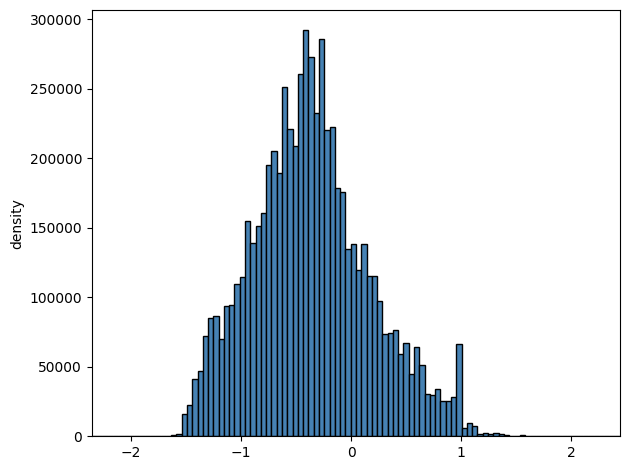

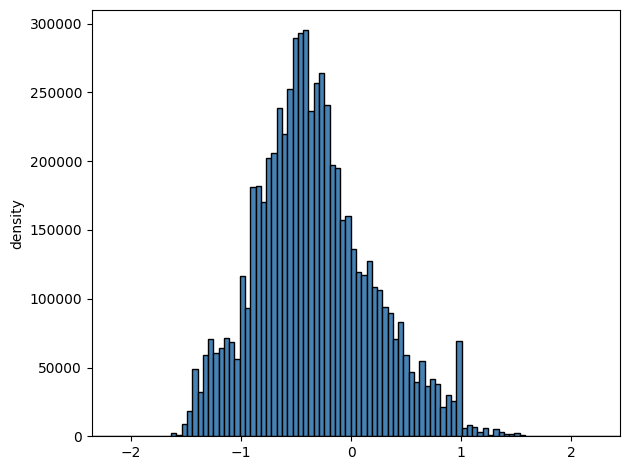

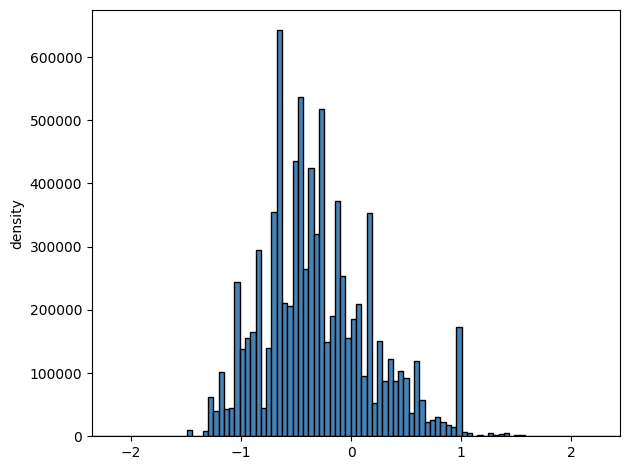

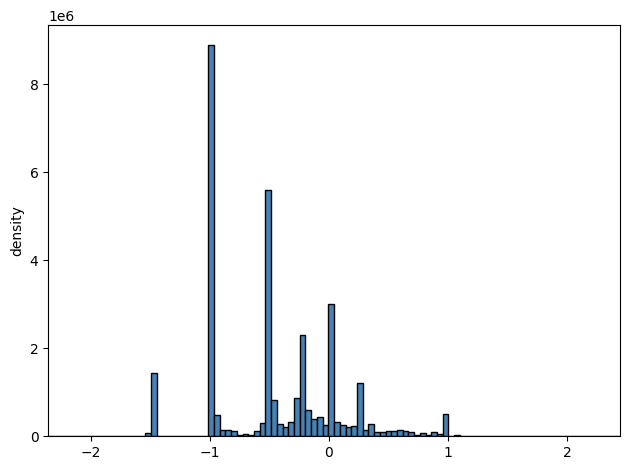

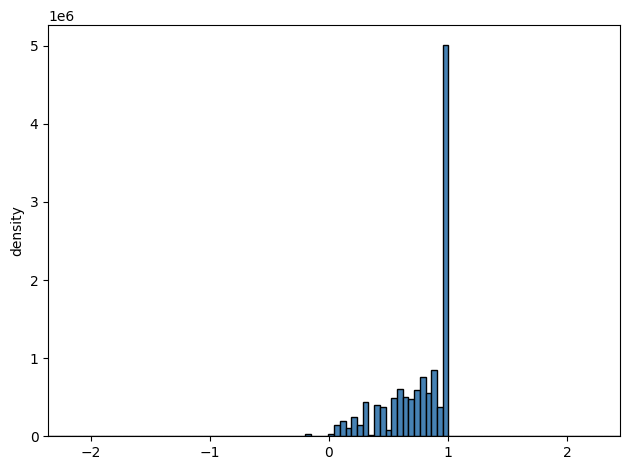

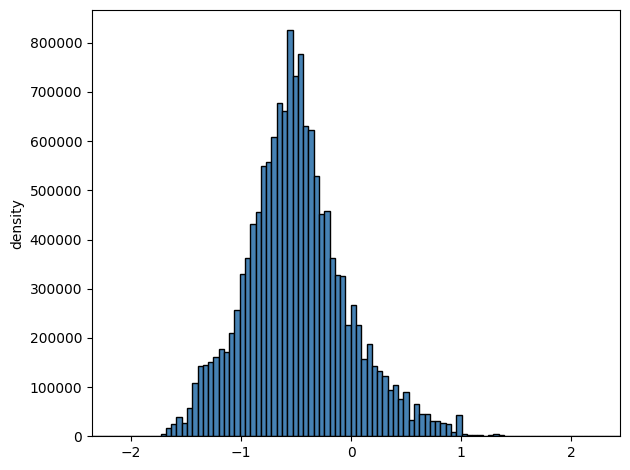

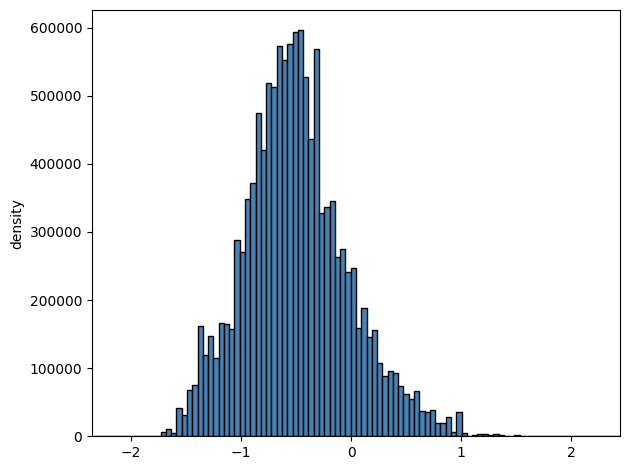

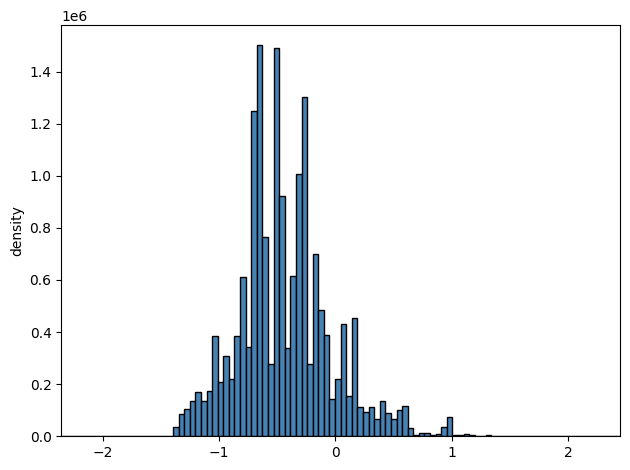

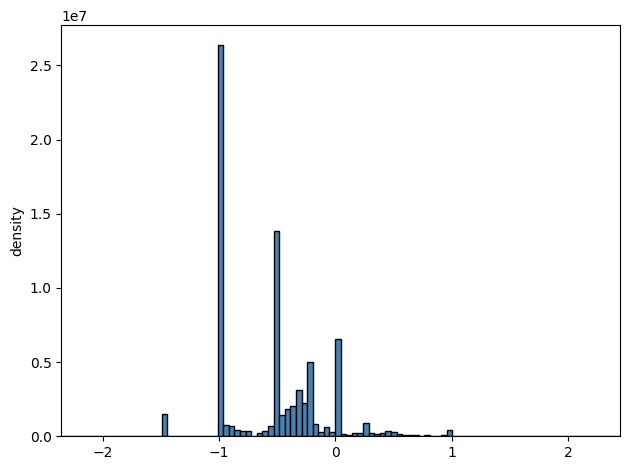

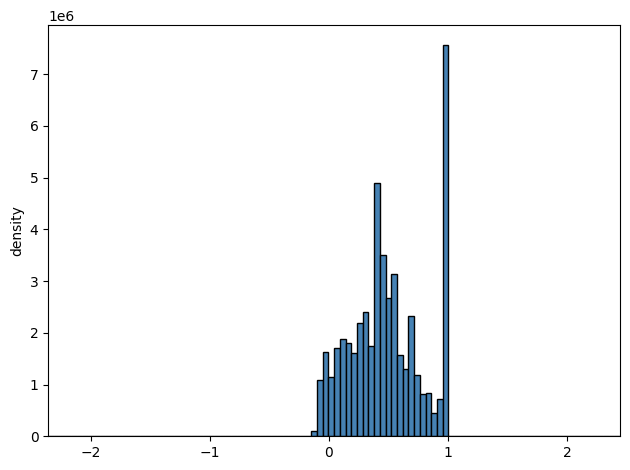

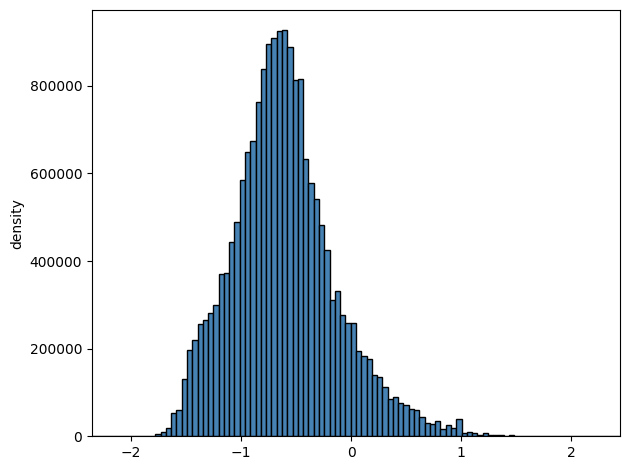

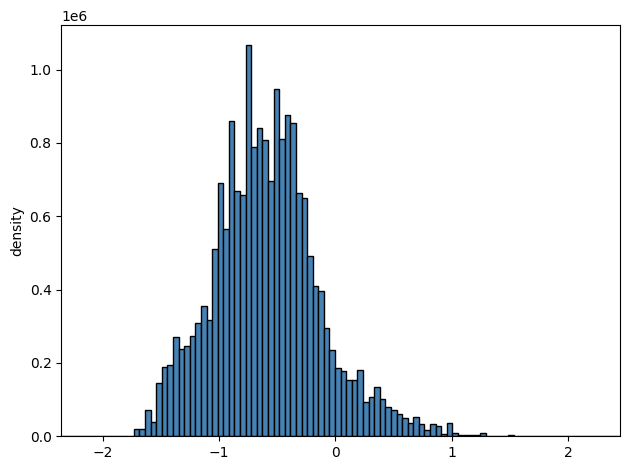

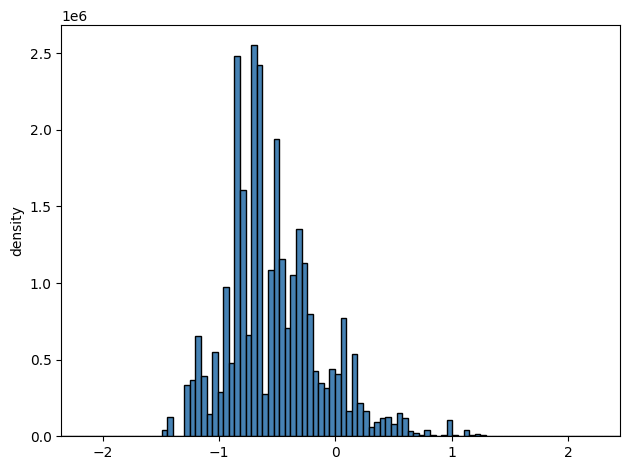

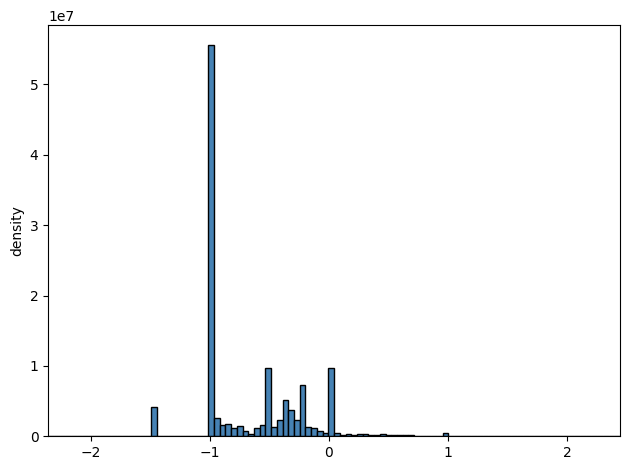

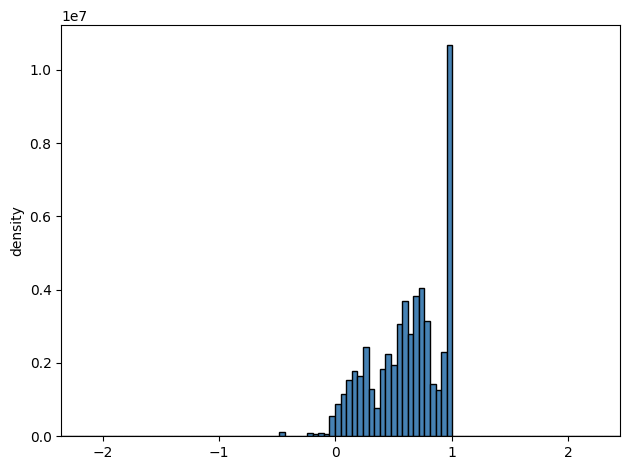

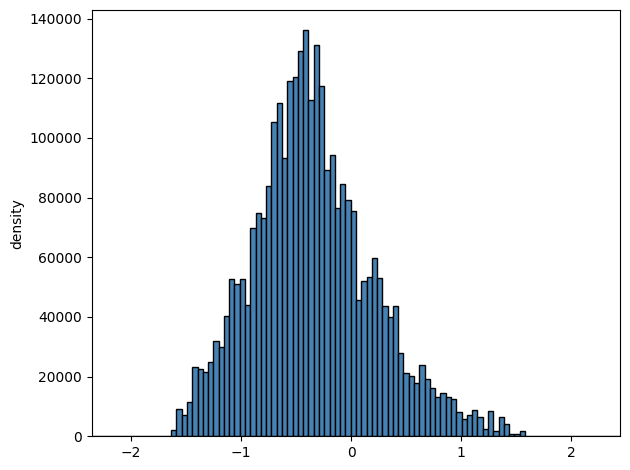

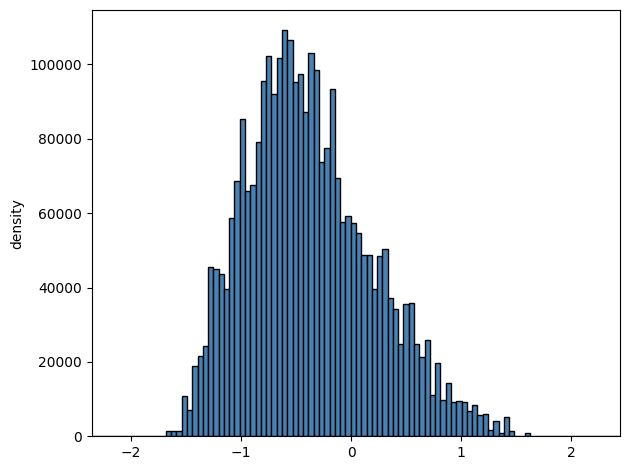

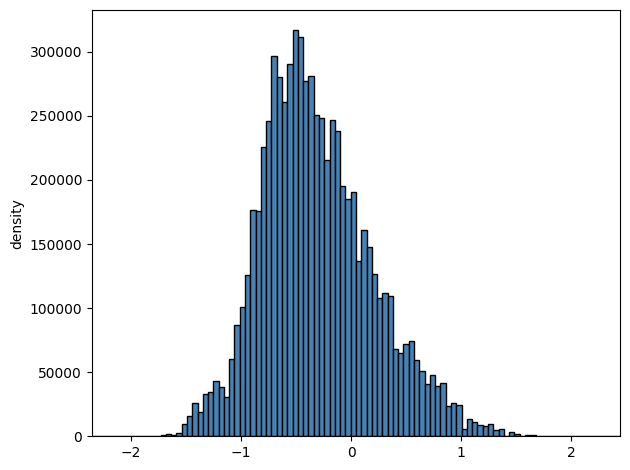

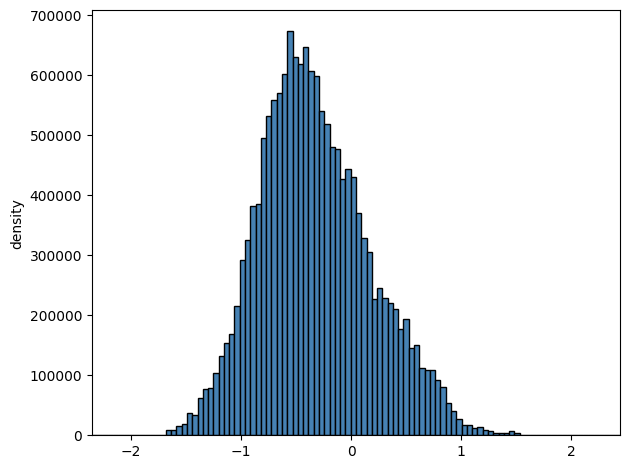

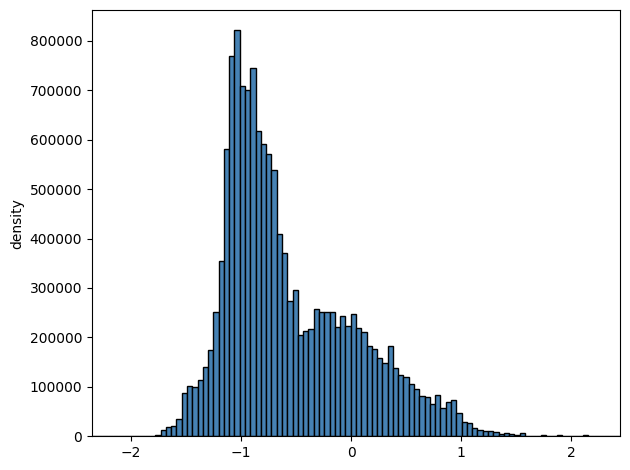

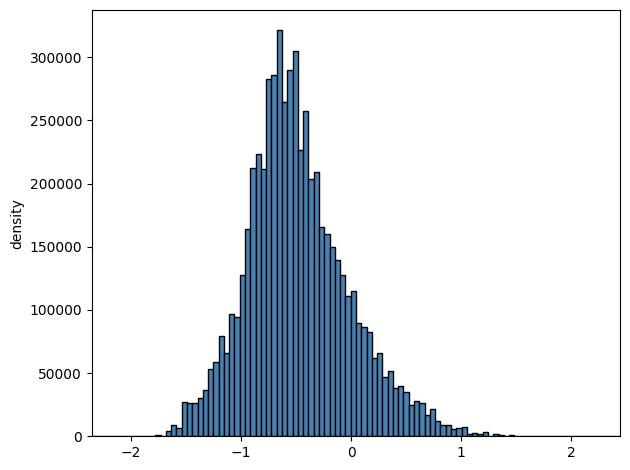

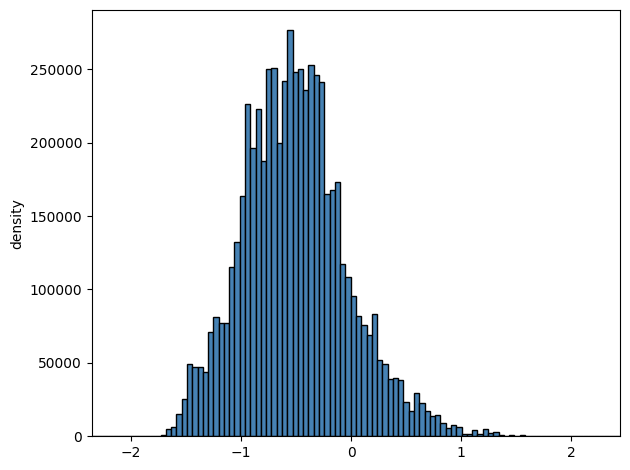

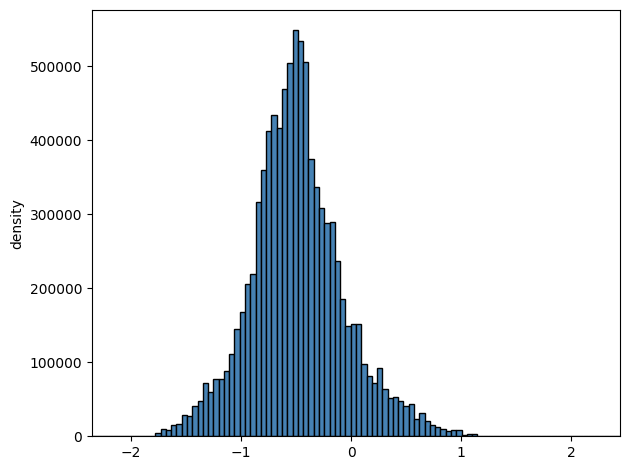

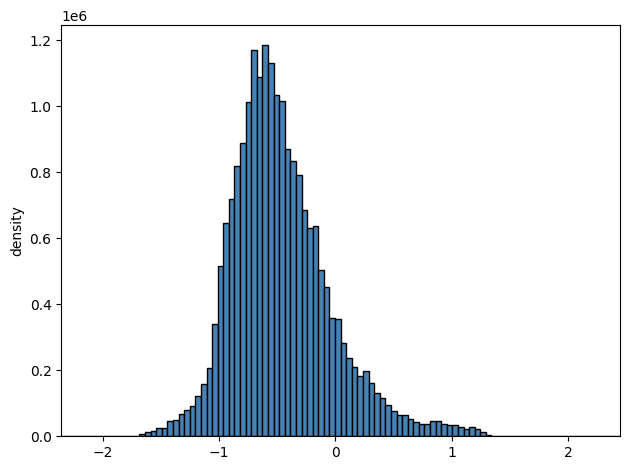

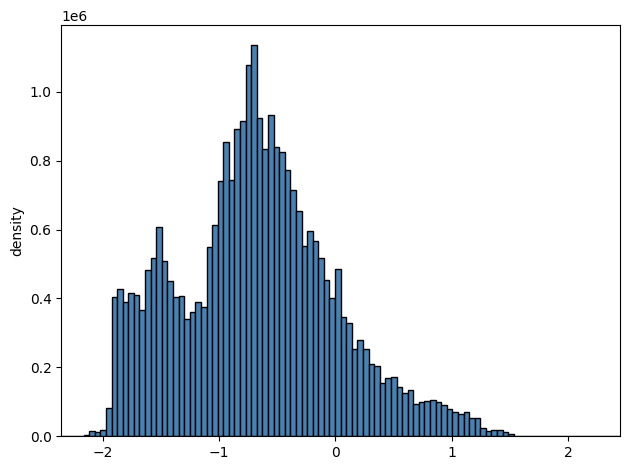

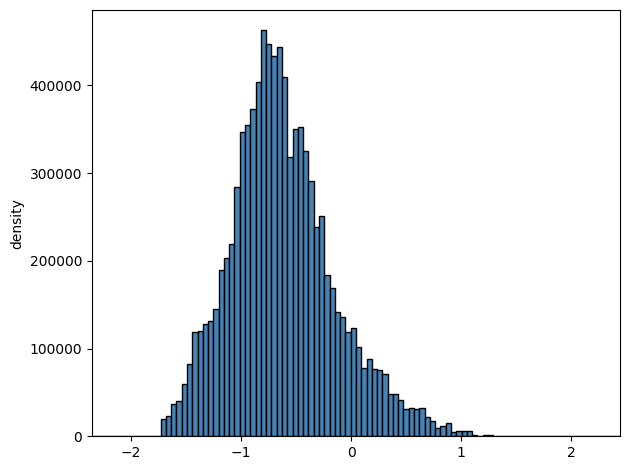

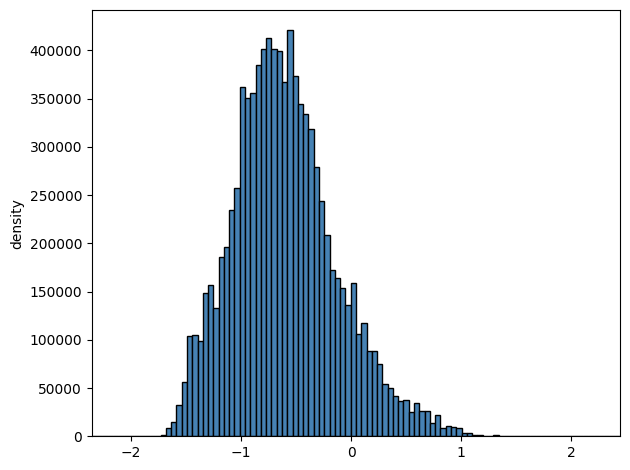

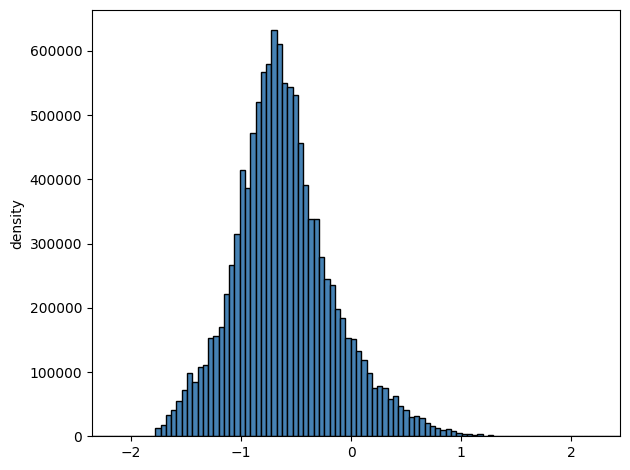

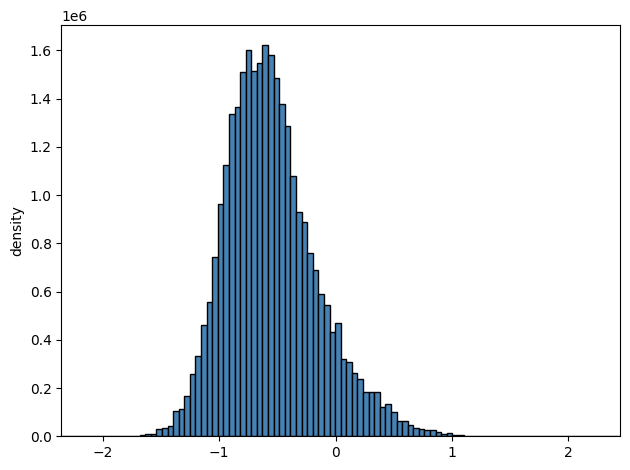

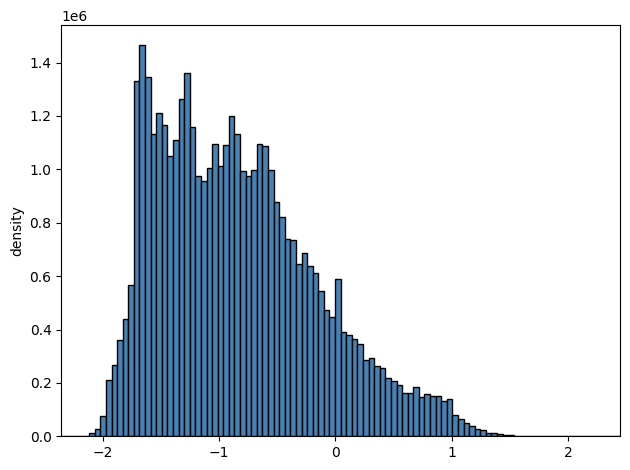

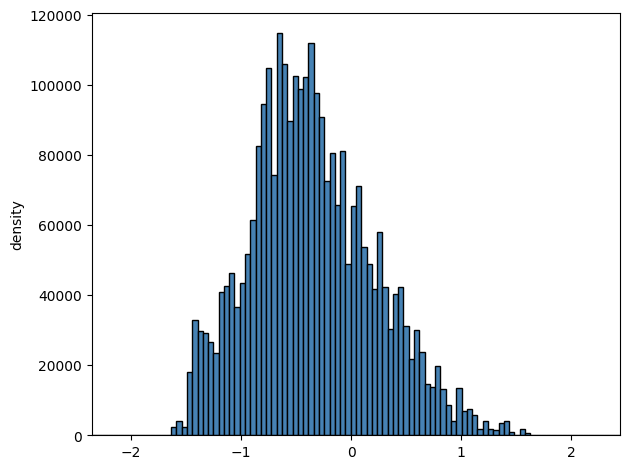

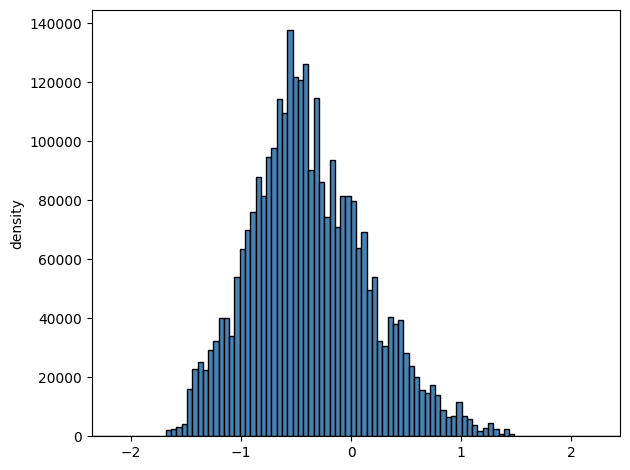

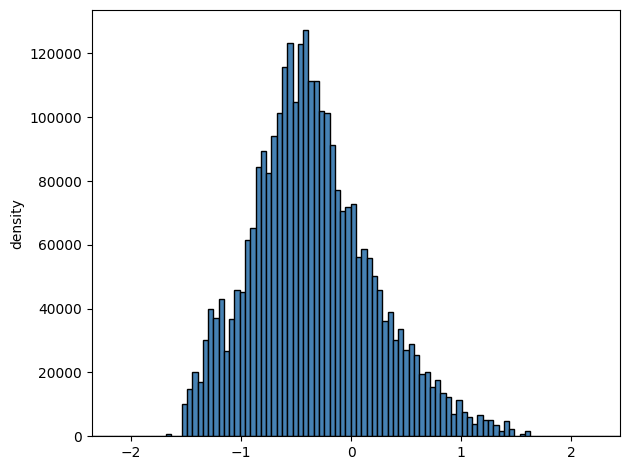

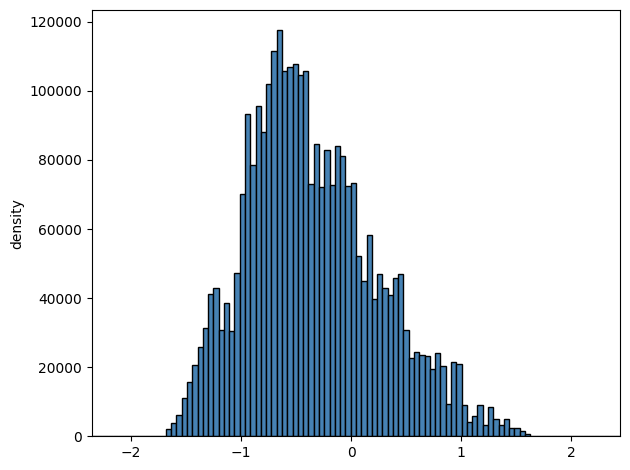

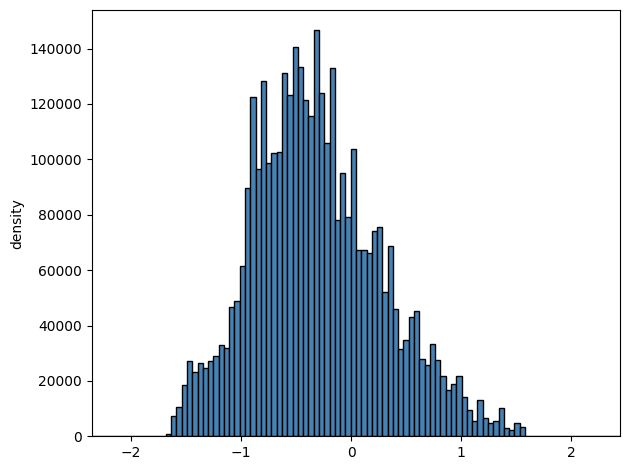

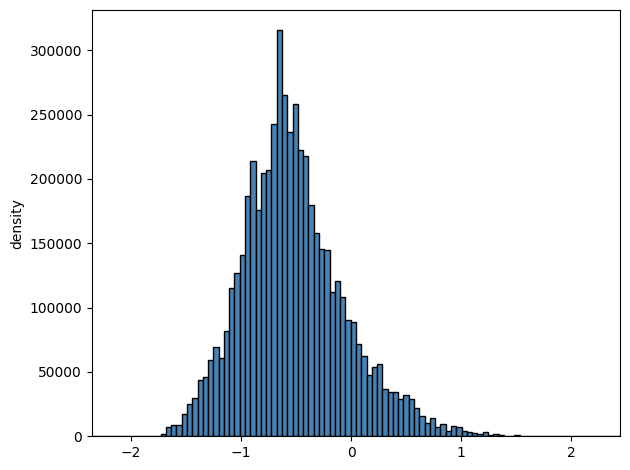

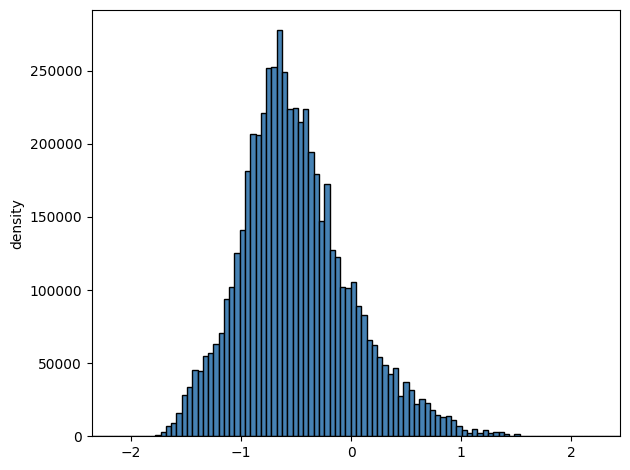

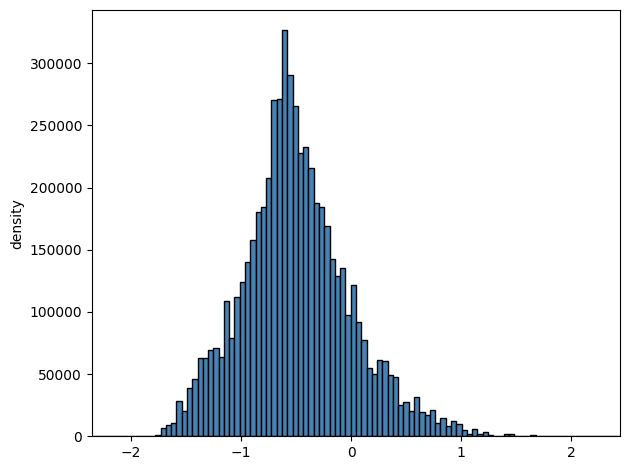

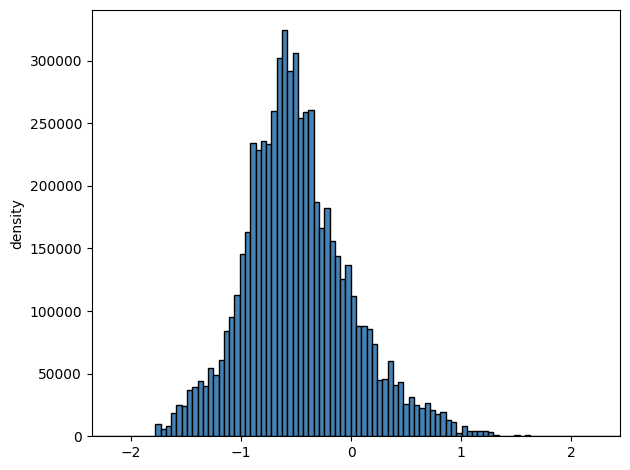

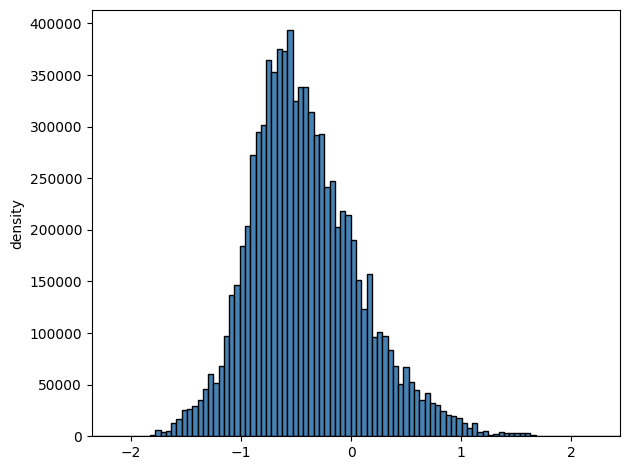

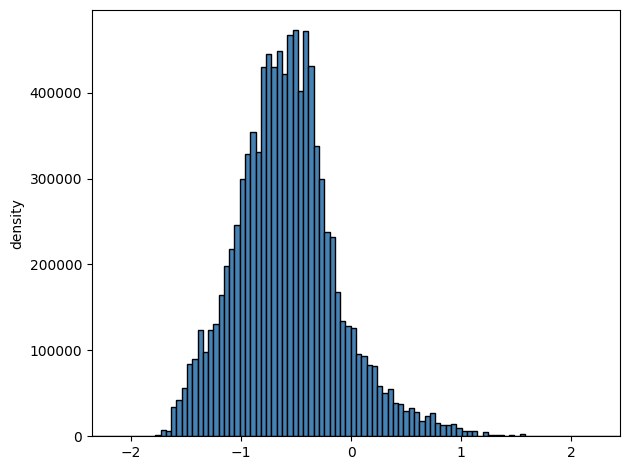

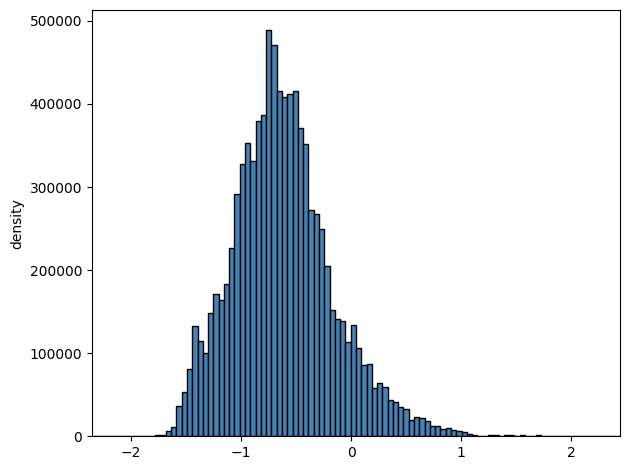

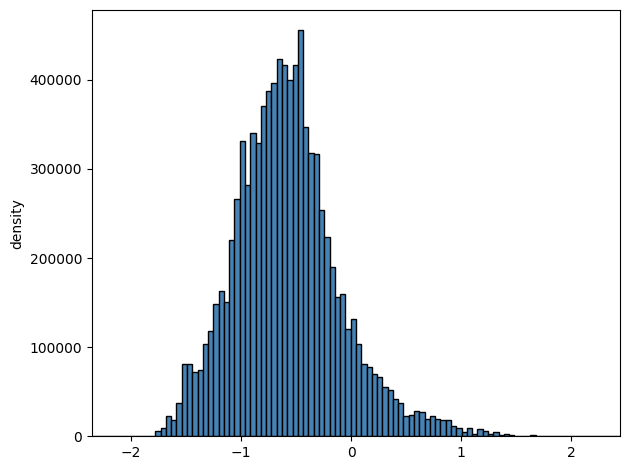

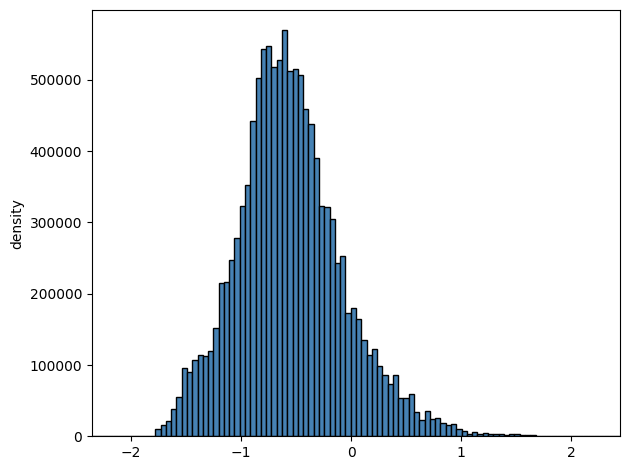

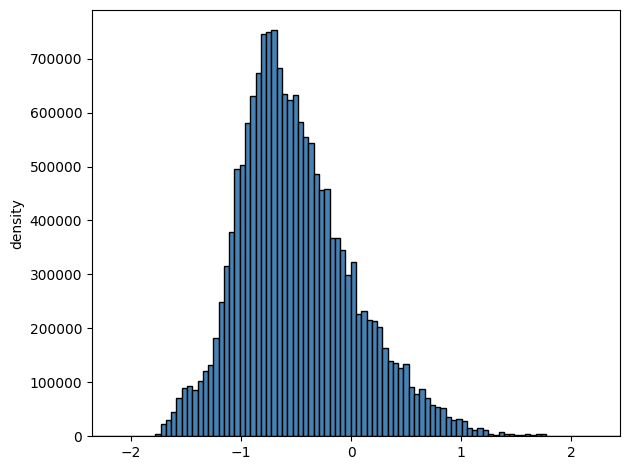

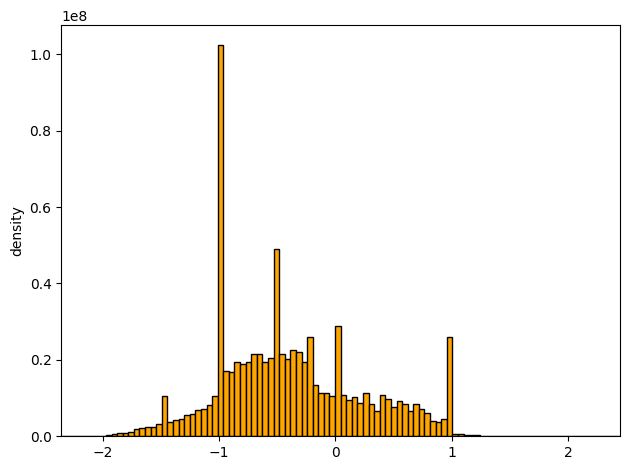

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_states(json_path):
    """states ヒストグラムを読み込み、(hists, edges) のリストを返す"""
    with open(json_path) as f:
        data = json.load(f)
    hists, edges_list = [], []
    for d in data:
        if "states" not in d:
            continue
        st = d["states"]
        h = np.asarray(st["hist"], dtype=float)
        e = np.linspace(st["min"], st["max"], len(h) + 1)
        hists.append(h)
        edges_list.append(e)
    return hists, edges_list

def rebin_hist(hist, edges_src, edges_dst):
    """edges_src にあるヒストを edges_dst に再ビン"""
    centers = 0.5 * (edges_src[:-1] + edges_src[1:])
    widths = np.diff(edges_src)
    out = np.zeros(len(edges_dst) - 1, dtype=float)
    for c, cnt, w in zip(centers, hist, widths):
        idx = np.searchsorted(edges_dst, c, side="right") - 1
        if 0 <= idx < len(out):
            out[idx] += cnt if w <= 0 else cnt / w
    return out
json_paths = [
    "/work/robomimic/quantize_logs/CAM/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_2bit.json",
]           
def plot_multi_states(json_paths, nbins=100, use_density=True):
    all_hists, all_edges = [], []
    for p in json_paths:
        h, e = load_states(p)
        all_hists.extend(h); all_edges.extend(e)
    if not all_hists:
        print("states hist is empty"); return

    vmin = min(e.min() for e in all_edges)
    vmax = max(e.max() for e in all_edges)
    common_edges = np.linspace(vmin, vmax, nbins + 1)
    widths = np.diff(common_edges)
    centers = 0.5 * (common_edges[:-1] + common_edges[1:])
    ylabel = "density" if use_density else "count"

    # ファイルごと
    for p in json_paths:
        h, e = load_states(p)
        if not h:
            continue
        reb = [rebin_hist(hi, ei, common_edges) for hi, ei in zip(h, e)]
        hist_sum = np.sum(reb, axis=0)
        y = hist_sum / widths if use_density else hist_sum
        plt.bar(
            centers, y, width=widths, align="center",
            edgecolor="black", linewidth=1.0,
            color="steelblue", alpha=1.0
        )
        plt.ylabel(ylabel)
        plt.xlim(vmin, vmax)
        plt.tight_layout()
        plt.show()

    # 全ファイル合算
    reb_all = [rebin_hist(h, e, common_edges) for h, e in zip(all_hists, all_edges)]
    hist_sum_all = np.sum(reb_all, axis=0)
    y_all = hist_sum_all / widths if use_density else hist_sum_all
    plt.bar(
        centers, y_all, width=widths, align="center",
        edgecolor="black", linewidth=1.0,
        color="orange", alpha=1.0
    )
    plt.ylabel(ylabel)
    plt.xlim(vmin, vmax)
    plt.tight_layout()
    plt.show()

# 例: density 表示（デフォルト）
plot_multi_states(json_paths, nbins=100, use_density=True)
# ...existing code...

In [ ]:
import json
def print_global_minmax(json_paths, key="states"):
    g_min, g_max = float("inf"), float("-inf")
    found = False
    for p in json_paths:
        try:
            with open(p) as f:
                data = json.load(f)
        except Exception as e:
            print(f"[skip] {p}: {e}")
            continue
        for d in data:
            if key not in d:
                continue
            g_min = min(g_min, d[key]["min"])
            g_max = max(g_max, d[key]["max"])
            found = True
    if not found:
        print(f"{key}: no data found")
    else:
        print(f"{key}: global min={g_min}, global max={g_max}")

# 使い方（複数ファイルを渡す）
json_paths = [
    "/work/robomimic/quantize_logs/CAM/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/CAM/uunit256_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/Weight/uunit256_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit64_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit128_2bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_8bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_6bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_4bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_3bit.json",
    "/work/robomimic/quantize_logs/LUT/uunit256_2bit.json",
]           
print_global_minmax(json_paths, key="states")
print_global_minmax(json_paths, key="activations")

states: global min=-2.3560047149658203, global max=2.445286989212036
activations: global min=0.0, global max=1.0
